# AI-Based Intrusion Detection System
### Using Machine Learning to Detect Malicious Network Traffic
---
This notebook implements a supervised machine learning pipeline to classify network traffic as benign or malicious using the CICIDS2017 dataset. The system detects DDoS attacks and Port Scans using a Random Forest classifier.

## 1. Setup & Data Loading
We begin by mounting Google Drive to access our dataset, then loading the three CSV files from the CICIDS2017 dataset — Monday (benign traffic), Friday DDoS, and Friday PortScan.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os

dataset_path = "/content/drive/MyDrive/Muddassir Mini Project/IDS Project/dataset"
files = os.listdir(dataset_path)
for f in files:
    print(f)

Wednesday-workingHours.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [3]:
import pandas as pd
import numpy as np

monday = pd.read_csv(dataset_path + "/Monday-WorkingHours.pcap_ISCX.csv")
ddos = pd.read_csv(dataset_path + "/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
portscan = pd.read_csv(dataset_path + "/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")

monday.columns = monday.columns.str.strip()
ddos.columns = ddos.columns.str.strip()
portscan.columns = portscan.columns.str.strip()

print("Monday shape:", monday.shape)
print("DDoS shape:", ddos.shape)
print("PortScan shape:", portscan.shape)

Monday shape: (529918, 79)
DDoS shape: (225745, 79)
PortScan shape: (286467, 79)


## 2. Exploratory Data Analysis
Before preprocessing, we explore the dataset to understand its structure, column names, label distribution, and class balance across the three traffic types.

In [4]:
monday.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
print("Monday labels:")
print(monday["Label"].value_counts())

print("\nDDoS labels:")
print(ddos["Label"].value_counts())

print("\nPortScan labels:")
print(portscan["Label"].value_counts())

Monday labels:
Label
BENIGN    529918
Name: count, dtype: int64

DDoS labels:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

PortScan labels:
Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64


## 3. Data Preprocessing
We combine all three DataFrames into one, handle missing values, remove infinite values caused by division by zero in flow calculations, and verify the cleaned dataset is ready for training.

In [6]:
import pandas as pd

df = pd.concat([monday, ddos, portscan], ignore_index=True)

print("Combined shape:", df.shape)
print("\nAll labels:")
print(df["Label"].value_counts())

Combined shape: (1042130, 79)

All labels:
Label
BENIGN      755173
PortScan    158930
DDoS        128027
Name: count, dtype: int64


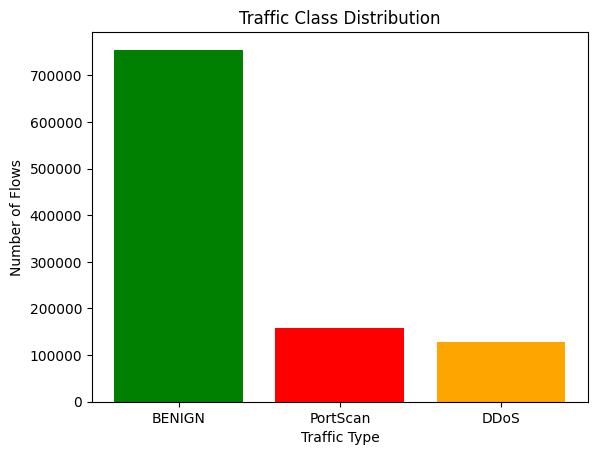

In [7]:
import matplotlib.pyplot as plt

label_counts = df["Label"].value_counts()

plt.bar(label_counts.index, label_counts.values, color=["green", "red", "orange"])
plt.title("Traffic Class Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Flows")
plt.show()

In [8]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64


In [9]:
import numpy as np

inf_counts = np.isinf(df.select_dtypes(include=np.number)).sum()
print("Infinite values per column:")
print(inf_counts[inf_counts > 0])

Infinite values per column:
Flow Bytes/s      759
Flow Packets/s    842
dtype: int64


In [10]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (1041288, 79)


In [11]:
print("Label distribution after cleaning:")
print(df["Label"].value_counts())

Label distribution after cleaning:
Label
BENIGN      754459
PortScan    158804
DDoS        128025
Name: count, dtype: int64


## 4. Feature Engineering
We separate features (X) from labels (y), encode text labels into numeric values, normalize all features using StandardScaler, and split the data into 80% training and 20% testing sets.

In [12]:
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=["Label"])
y = df["Label"]

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)
print("Encoded sample:", y_encoded[:5])

Classes: ['BENIGN' 'DDoS' 'PortScan']
Encoded sample: [0 0 0 0 0]


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done. Shape:", X_scaled.shape)

Scaling done. Shape: (1041288, 78)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (833030, 78)
Testing set size: (208258, 78)


## 5. Model Training & Evaluation
We train and evaluate four classification models — Random Forest, Logistic Regression, SVM (LinearSVC), and Decision Tree. Each model is assessed using Accuracy, Precision, Recall, F1-score, and a Confusion Matrix.

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest training complete.")

Random Forest training complete.


In [16]:
from sklearn.metrics import classification_report

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf, target_names=encoder.classes_))

Random Forest Results:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    150892
        DDoS       1.00      1.00      1.00     25605
    PortScan       1.00      1.00      1.00     31761

    accuracy                           1.00    208258
   macro avg       1.00      1.00      1.00    208258
weighted avg       1.00      1.00      1.00    208258



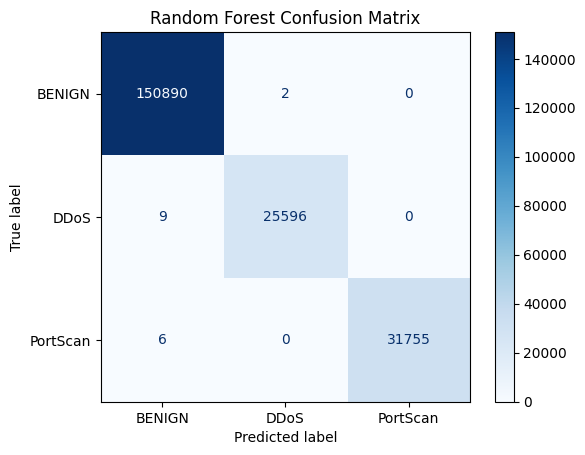

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [19]:
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr, target_names=encoder.classes_))

Logistic Regression Results:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    150892
        DDoS       1.00      0.99      0.99     25605
    PortScan       0.99      1.00      0.99     31761

    accuracy                           1.00    208258
   macro avg       1.00      0.99      0.99    208258
weighted avg       1.00      1.00      1.00    208258



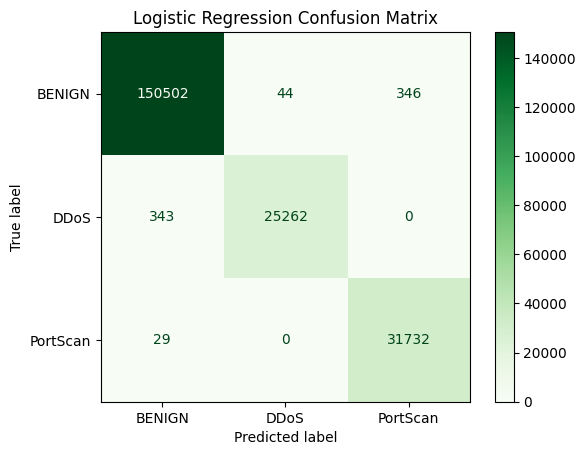

In [20]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=encoder.classes_)
disp_lr.plot(cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [21]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train, y_train,
    test_size=0.9,
    random_state=42,
    stratify=y_train
)

print("SVM sample size:", X_train_svm.shape)

svm_model = LinearSVC(max_iter=5000, random_state=42, C=1.0)
svm_model.fit(X_train_svm, y_train_svm)

print("SVM training complete.")

SVM sample size: (83303, 78)
SVM training complete.


In [22]:
y_pred_svm = svm_model.predict(X_test)

print("SVM Results:")
print(classification_report(y_test, y_pred_svm, target_names=encoder.classes_))

SVM Results:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    150892
        DDoS       1.00      0.99      0.99     25605
    PortScan       0.98      1.00      0.99     31761

    accuracy                           1.00    208258
   macro avg       0.99      1.00      0.99    208258
weighted avg       1.00      1.00      1.00    208258



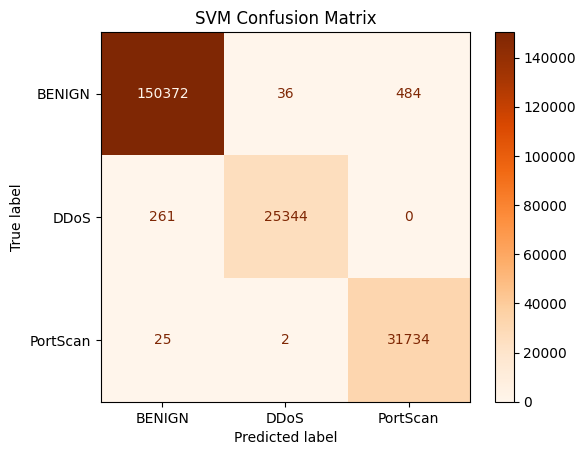

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=encoder.classes_)
disp_svm.plot(cmap="Oranges")
plt.title("SVM Confusion Matrix")
plt.show()

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=20, random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree training complete.")

Decision Tree training complete.


In [25]:
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Results:")
print(classification_report(y_test, y_pred_dt, target_names=encoder.classes_))

Decision Tree Results:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    150892
        DDoS       1.00      1.00      1.00     25605
    PortScan       1.00      1.00      1.00     31761

    accuracy                           1.00    208258
   macro avg       1.00      1.00      1.00    208258
weighted avg       1.00      1.00      1.00    208258



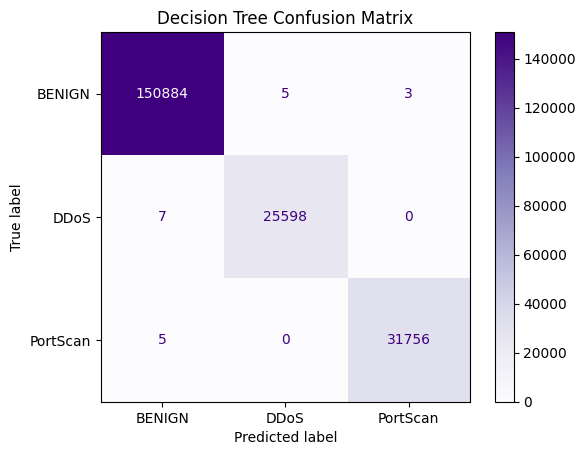

In [26]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=encoder.classes_)
disp_dt.plot(cmap="Purples")
plt.title("Decision Tree Confusion Matrix")
plt.show()

## 6. Model Optimization
We apply 5-fold cross validation to verify model consistency, then use GridSearchCV to find the optimal hyperparameters for our Random Forest model. The best model is retrained and evaluated.

In [27]:
from sklearn.model_selection import cross_val_score, train_test_split

X_cv, _, y_cv, _ = train_test_split(
    X_scaled, y_encoded,
    test_size=0.9,
    random_state=42,
    stratify=y_encoded
)

print("Cross validation sample size:", X_cv.shape)

scores = cross_val_score(rf_model, X_cv, y_cv, cv=5, scoring="accuracy", n_jobs=-1)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Cross validation sample size: (104128, 78)
Cross Validation Scores: [0.99985595 0.99975992 0.99985595 0.99990396 0.99980792]
Mean Accuracy: 0.9998367397664915
Standard Deviation: 4.896764326657228e-05


In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_cv, y_cv)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best Accuracy: 0.9998175324523993


In [29]:
from sklearn.ensemble import RandomForestClassifier
import pickle

best_rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

best_rf_model.fit(X_train, y_train)
print("Best model training complete.")

with open("/content/drive/MyDrive/Muddassir Mini Project/IDS Project/ids_model.pkl", "wb") as f:
    pickle.dump(best_rf_model, f)

print("Best model saved successfully.")

Best model training complete.
Best model saved successfully.


In [30]:
y_pred_best = best_rf_model.predict(X_test)

print("Best Model Results:")
print(classification_report(y_test, y_pred_best, target_names=encoder.classes_))

Best Model Results:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    150892
        DDoS       1.00      1.00      1.00     25605
    PortScan       1.00      1.00      1.00     31761

    accuracy                           1.00    208258
   macro avg       1.00      1.00      1.00    208258
weighted avg       1.00      1.00      1.00    208258



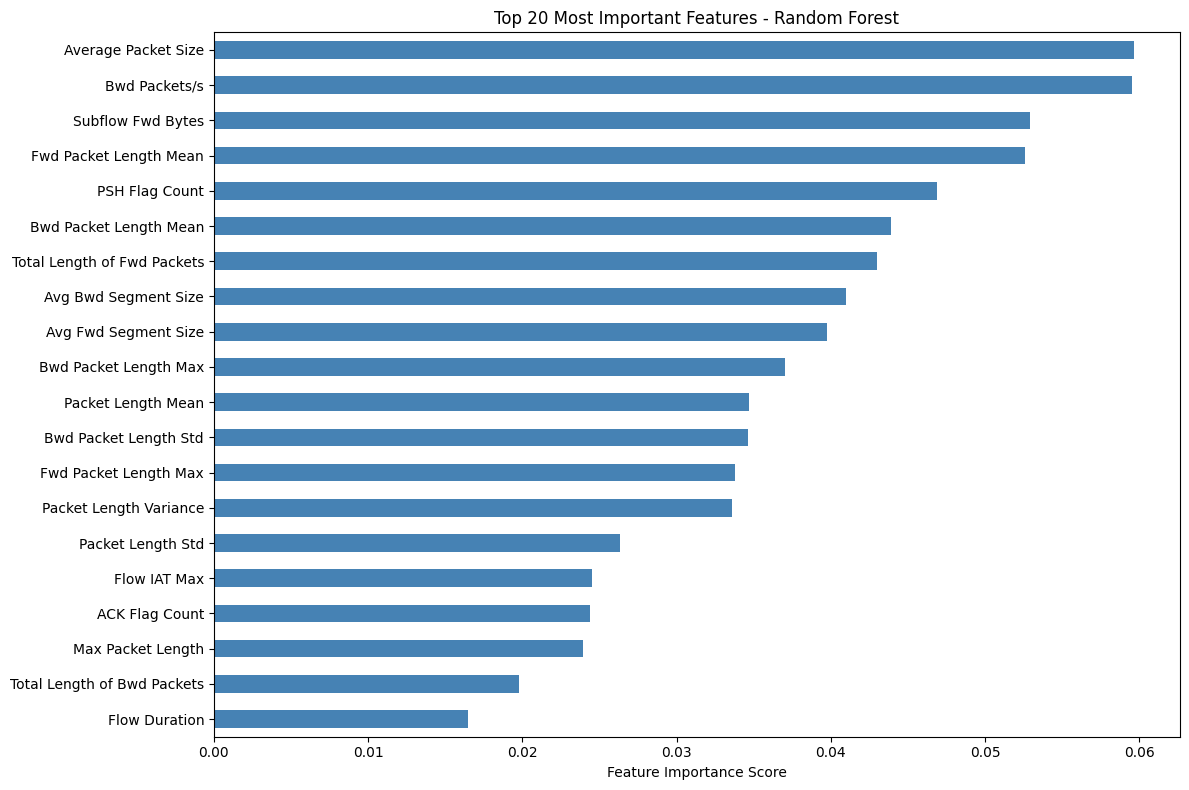

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X.columns.tolist()
importances = best_rf_model.feature_importances_

feat_series = pd.Series(importances, index=feature_names)
top20 = feat_series.sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
top20.plot(kind="barh", color="steelblue")
plt.title("Top 20 Most Important Features - Random Forest")
plt.xlabel("Feature Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

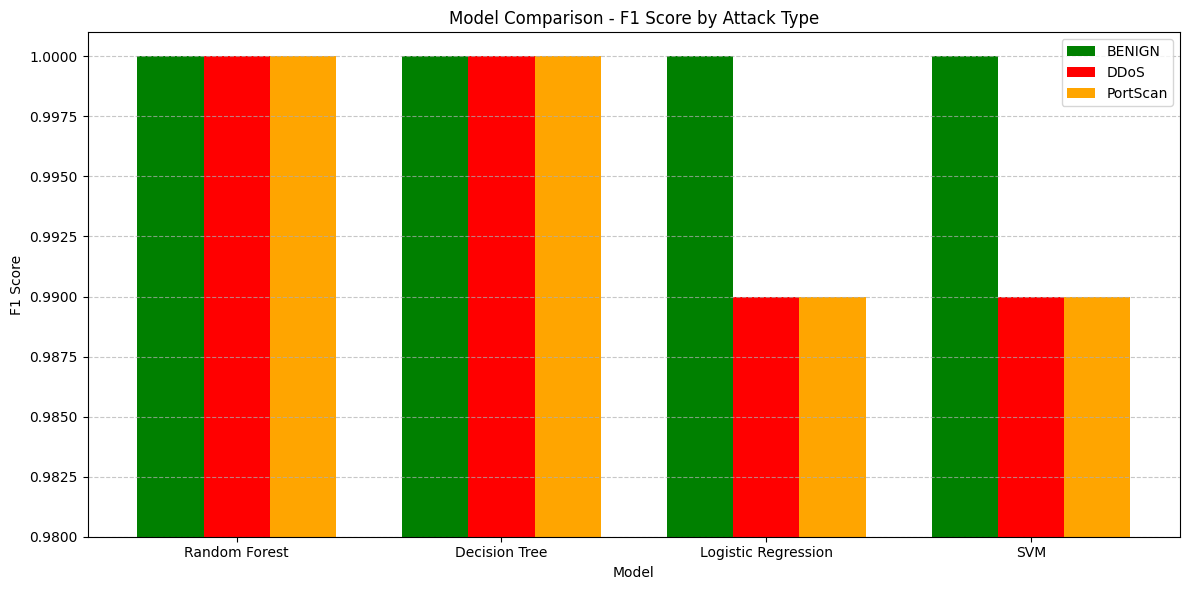

In [34]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Random Forest", "Decision Tree", "Logistic Regression", "SVM"]

benign_f1    = [1.00, 1.00, 1.00, 1.00]
ddos_f1      = [1.00, 1.00, 0.99, 0.99]
portscan_f1  = [1.00, 1.00, 0.99, 0.99]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, benign_f1,   width, label="BENIGN",   color="green")
bars2 = ax.bar(x,         ddos_f1,     width, label="DDoS",     color="red")
bars3 = ax.bar(x + width, portscan_f1, width, label="PortScan", color="orange")

ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.set_title("Model Comparison - F1 Score by Attack Type")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim([0.98, 1.001])
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## 7. Learning Curve
The learning curve shows how model accuracy improves as more training data is added, confirming the model generalizes well and is not overfitting.

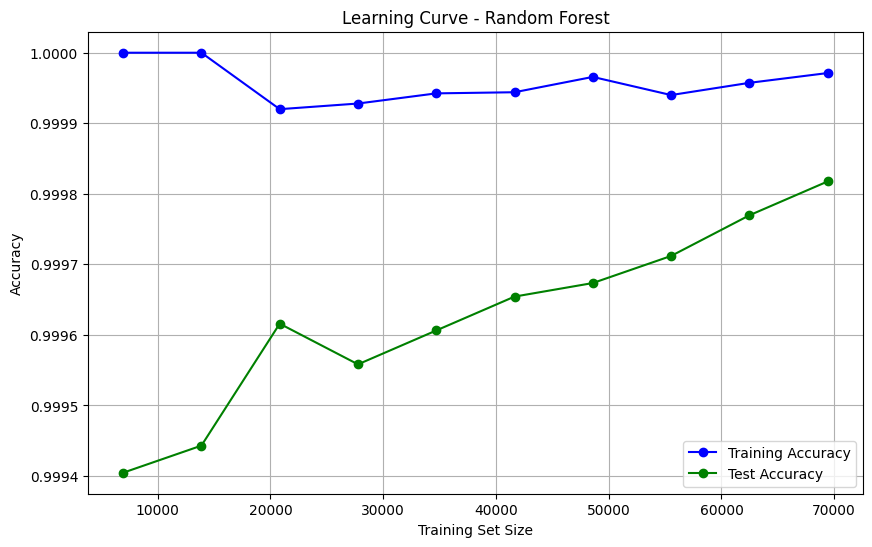

In [32]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    best_rf_model,
    X_cv, y_cv,
    cv=3,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Training Accuracy", color="blue", marker="o")
plt.plot(train_sizes, test_mean, label="Test Accuracy", color="green", marker="o")
plt.title("Learning Curve - Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 8. Save Model
The optimized Random Forest model and StandardScaler are saved using pickle to Google Drive for use in the CLI-based IDS tool.

In [33]:
import pickle

model_path = "/content/drive/MyDrive/Muddassir Mini Project/IDS Project/"

with open(model_path + "ids_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open(model_path + "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


## Conclusion

This project successfully demonstrates the application of supervised machine learning for network intrusion detection. Using the CICIDS2017 dataset, we trained and evaluated four classification models — Random Forest, Decision Tree, Logistic Regression, and SVM.

The Random Forest classifier achieved the best performance with 99.99% accuracy and perfect F1 scores across all three traffic classes (BENIGN, DDoS, PortScan), with only 17 misclassifications out of 208,258 test samples.

Feature importance analysis revealed that packet size related features such as Average Packet Size, Bwd Packets/s, and Fwd Packet Length Mean are the most discriminative for identifying malicious traffic. The learning curve confirmed that the model generalizes well and does not overfit.

The trained model was deployed as a Python CLI tool that accepts network traffic CSV files and outputs color coded, timestamped classifications in real time.

**Future work** includes extending the system to support all CICIDS2017 attack categories, integrating live network monitoring, and implementing automatic IP blocking via firewall rules.